In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
from scipy.linalg import solve

Total nodes: 16
Sample nodes:
  Node 1: [0 0]
  Node 2: [6000    0]
  Node 5: [   0 3000]
  Node 16: [18000  9000]

Total elements: 21
Columns: 12
Beams: 9

Global stiffness matrix size: (48, 48)

Displacements at loaded nodes:
  Node 5: ux=2.6445 mm, uy=0.0220 mm, θz=-0.000919 rad
  Node 9: ux=5.6722 mm, uy=0.0334 mm, θz=-0.000652 rad
  Node 13: ux=7.4614 mm, uy=0.0371 mm, θz=-0.000340 rad

Element Forces (first 5 elements):
  Element 1 (column): N1=35.19 kN, V1=-34.13 kN, M1=-70.80 kN·m
  Element 2 (column): N1=18.29 kN, V1=-18.10 kN, M1=-21.46 kN·m
  Element 3 (column): N1=5.92 kN, V1=-8.13 kN, M1=-5.52 kN·m
  Element 4 (column): N1=-4.25 kN, V1=-42.01 kN, M1=-77.85 kN·m
  Element 5 (column): N1=-1.96 kN, V1=-31.61 kN, M1=-44.01 kN·m


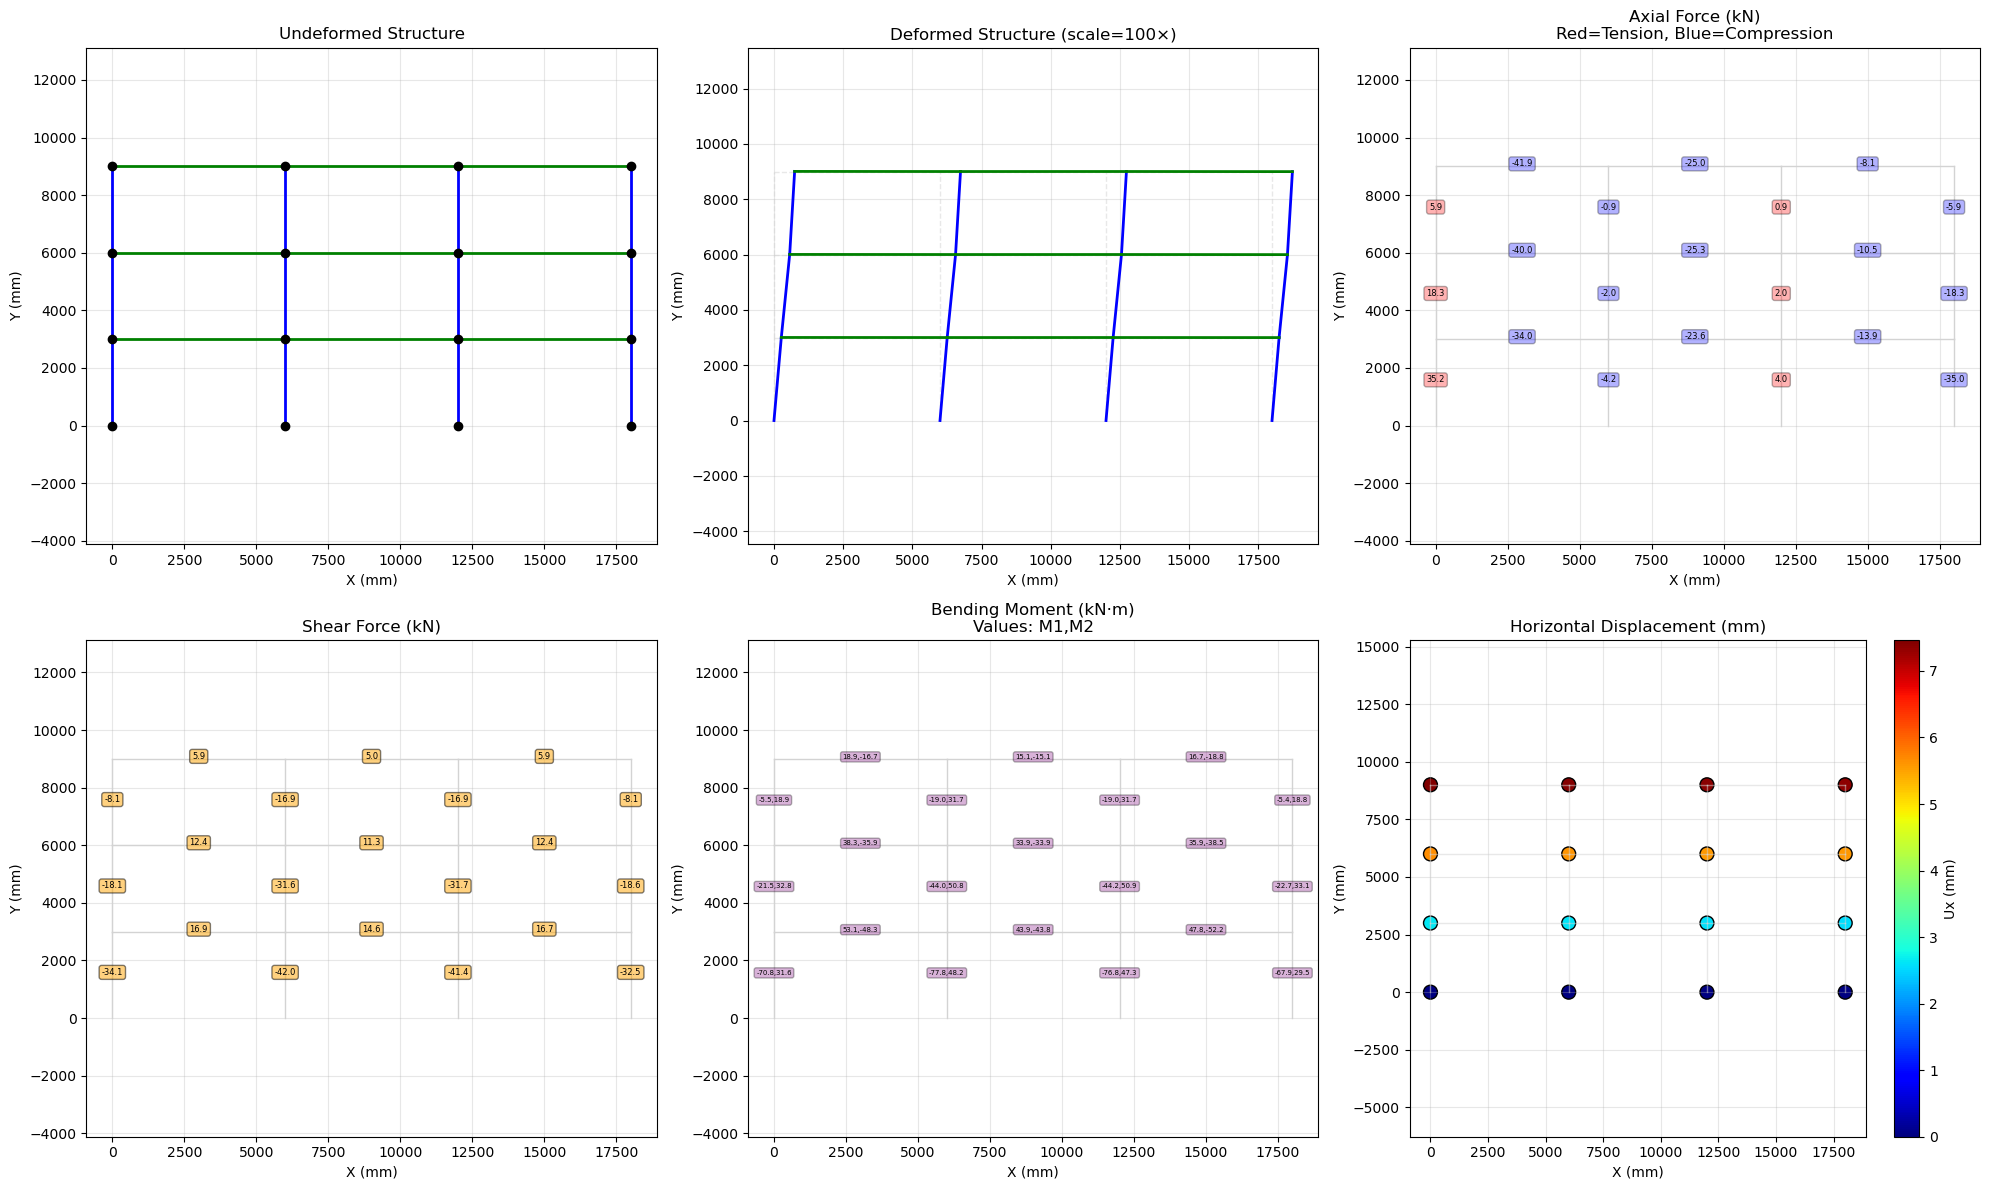


SUMMARY RESULTS

Maximum horizontal displacement: 7.4614 mm
Maximum vertical displacement: 0.0371 mm
Maximum rotation: 0.000919 rad

Maximum axial force: 41.87 kN
Maximum shear force: 42.01 kN
Maximum bending moment: 77.85 kN·m



In [4]:
# Material and geometric properties
E = 3.0e4  # MPa
nu = 0.3
b = 400  # mm (out-of-plane width)
h = 400  # mm (in-plane height)
L_span = 6000  # mm
H_floor = 3000  # mm

# Section properties
A = b * h  # mm^2
I = b * h**3 / 12  # mm^4 (moment of inertia about z-axis)
G = E / (2 * (1 + nu))  # Shear modulus
A_s = 5/6 * A  # Effective shear area for rectangular section

# Generate nodal coordinates
nodes = {}
node_id = 0
for j in range(4):  # Y positions (floors)
    for i in range(4):  # X positions (bays)
        node_id += 1
        x = i * L_span
        y = j * H_floor
        nodes[node_id] = np.array([x, y])

print(f"Total nodes: {len(nodes)}")
print("Sample nodes:")
for nid in [1, 2, 5, 16]:
    print(f"  Node {nid}: {nodes[nid]}")

# Define elements (node1, node2)
elements = []

# Column elements (vertical)
for i in range(4):  # 4 X positions
    for j in range(3):  # 3 Y intervals
        node1 = j * 4 + i + 1
        node2 = (j + 1) * 4 + i + 1
        elements.append((node1, node2, 'column'))

# Beam elements (horizontal)
for j in range(1, 4):  # 3 floors (j=1,2,3 -> floor 2,3,4)
    for i in range(3):  # 3 X intervals
        node1 = j * 4 + i + 1
        node2 = j * 4 + i + 2
        elements.append((node1, node2, 'beam'))

print(f"\nTotal elements: {len(elements)}")
print(f"Columns: {sum(1 for e in elements if e[2] == 'column')}")
print(f"Beams: {sum(1 for e in elements if e[2] == 'beam')}")

# Element stiffness matrix in local coordinates (with shear deformation)
def local_stiffness_matrix(L, E, A, I, G, A_s):
    """
    2D Timoshenko beam element stiffness matrix (6x6)
    DOFs: [u1, v1, theta1, u2, v2, theta2]
    """
    phi = 12 * E * I / (G * A_s * L**2)  # Shear deformation parameter
    
    k = np.zeros((6, 6))
    
    # Axial terms
    k[0, 0] = E * A / L
    k[0, 3] = -E * A / L
    k[3, 0] = -E * A / L
    k[3, 3] = E * A / L
    
    # Bending terms with shear deformation
    k[1, 1] = 12 * E * I / (L**3 * (1 + phi))
    k[1, 2] = 6 * E * I / (L**2 * (1 + phi))
    k[1, 4] = -12 * E * I / (L**3 * (1 + phi))
    k[1, 5] = 6 * E * I / (L**2 * (1 + phi))
    
    k[2, 1] = 6 * E * I / (L**2 * (1 + phi))
    k[2, 2] = (4 + phi) * E * I / (L * (1 + phi))
    k[2, 4] = -6 * E * I / (L**2 * (1 + phi))
    k[2, 5] = (2 - phi) * E * I / (L * (1 + phi))
    
    k[4, 1] = -12 * E * I / (L**3 * (1 + phi))
    k[4, 2] = -6 * E * I / (L**2 * (1 + phi))
    k[4, 4] = 12 * E * I / (L**3 * (1 + phi))
    k[4, 5] = -6 * E * I / (L**2 * (1 + phi))
    
    k[5, 1] = 6 * E * I / (L**2 * (1 + phi))
    k[5, 2] = (2 - phi) * E * I / (L * (1 + phi))
    k[5, 4] = -6 * E * I / (L**2 * (1 + phi))
    k[5, 5] = (4 + phi) * E * I / (L * (1 + phi))
    
    return k

# Transformation matrix
def transformation_matrix(angle):
    """
    Transformation matrix from local to global coordinates
    """
    c = np.cos(angle)
    s = np.sin(angle)
    
    T = np.zeros((6, 6))
    T[0:2, 0:2] = [[c, s], [-s, c]]
    T[2, 2] = 1
    T[3:5, 3:5] = [[c, s], [-s, c]]
    T[5, 5] = 1
    
    return T

# Assemble global stiffness matrix
n_nodes = len(nodes)
n_dof = 3 * n_nodes  # 3 DOFs per node (ux, uy, theta_z)
K_global = np.zeros((n_dof, n_dof))

element_data = []

for elem_id, (n1, n2, elem_type) in enumerate(elements):
    coord1 = nodes[n1]
    coord2 = nodes[n2]
    
    dx = coord2[0] - coord1[0]
    dy = coord2[1] - coord1[1]
    L = np.sqrt(dx**2 + dy**2)
    angle = np.arctan2(dy, dx)
    
    # Local stiffness matrix
    k_local = local_stiffness_matrix(L, E, A, I, G, A_s)
    
    # Transformation matrix
    T = transformation_matrix(angle)
    
    # Global stiffness matrix for element
    k_global = T.T @ k_local @ T
    
    # Store element data
    element_data.append({
        'nodes': (n1, n2),
        'length': L,
        'angle': angle,
        'type': elem_type,
        'T': T,
        'k_local': k_local
    })
    
    # Assemble into global matrix
    dofs = [3*(n1-1), 3*(n1-1)+1, 3*(n1-1)+2, 3*(n2-1), 3*(n2-1)+1, 3*(n2-1)+2]
    
    for i in range(6):
        for j in range(6):
            K_global[dofs[i], dofs[j]] += k_global[i, j]

print(f"\nGlobal stiffness matrix size: {K_global.shape}")

# Apply boundary conditions
# Bottom nodes (j=0): nodes 1, 2, 3, 4 are fully fixed
fixed_dofs = []
for i in range(4):
    node = i + 1
    fixed_dofs.extend([3*(node-1), 3*(node-1)+1, 3*(node-1)+2])

# Apply loads
F_global = np.zeros(n_dof)

# Horizontal forces at node (1,2), (1,3), (1,4)
# Node (1,2) is node 5, (1,3) is node 9, (1,4) is node 13
load_nodes = [5, 9, 13]
F_magnitude = 50000  # N = 50 kN converted to N

for node in load_nodes:
    F_global[3*(node-1)] = F_magnitude  # Force in x-direction

# Partition system
free_dofs = [i for i in range(n_dof) if i not in fixed_dofs]

K_ff = K_global[np.ix_(free_dofs, free_dofs)]
F_f = F_global[free_dofs]

# Solve for displacements
U_f = solve(K_ff, F_f)

# Construct full displacement vector
U_global = np.zeros(n_dof)
U_global[free_dofs] = U_f

print("\nDisplacements at loaded nodes:")
for node in load_nodes:
    ux = U_global[3*(node-1)]
    uy = U_global[3*(node-1)+1]
    theta = U_global[3*(node-1)+2]
    print(f"  Node {node}: ux={ux:.4f} mm, uy={uy:.4f} mm, θz={theta:.6f} rad")

# Calculate element forces
element_forces = []

for elem_id, elem in enumerate(element_data):
    n1, n2 = elem['nodes']
    
    # Global DOFs
    dofs = [3*(n1-1), 3*(n1-1)+1, 3*(n1-1)+2, 3*(n2-1), 3*(n2-1)+1, 3*(n2-1)+2]
    u_global = U_global[dofs]
    
    # Transform to local coordinates
    u_local = elem['T'] @ u_global
    
    # Calculate local forces
    f_local = elem['k_local'] @ u_local
    
    # Extract internal forces
    N1 = -f_local[0]  # Axial force at node 1
    V1 = -f_local[1]  # Shear force at node 1
    M1 = -f_local[2]  # Moment at node 1
    N2 = f_local[3]   # Axial force at node 2
    V2 = f_local[4]   # Shear force at node 2
    M2 = f_local[5]   # Moment at node 2
    
    element_forces.append({
        'N1': N1, 'V1': V1, 'M1': M1,
        'N2': N2, 'V2': V2, 'M2': M2
    })

# Convert to kN and kN·m for display
print("\nElement Forces (first 5 elements):")
for i in range(min(5, len(elements))):
    ef = element_forces[i]
    print(f"  Element {i+1} ({elements[i][2]}): N1={ef['N1']/1000:.2f} kN, "
          f"V1={ef['V1']/1000:.2f} kN, M1={ef['M1']/1e6:.2f} kN·m")

# Visualization
fig = plt.figure(figsize=(20, 12))

# 1. Undeformed structure
ax1 = plt.subplot(2, 3, 1)
for elem_id, (n1, n2, elem_type) in enumerate(elements):
    x = [nodes[n1][0], nodes[n2][0]]
    y = [nodes[n1][1], nodes[n2][1]]
    color = 'blue' if elem_type == 'column' else 'green'
    ax1.plot(x, y, color=color, linewidth=2)

for node_id, coord in nodes.items():
    ax1.plot(coord[0], coord[1], 'ko', markersize=6)
    
ax1.set_xlabel('X (mm)')
ax1.set_ylabel('Y (mm)')
ax1.set_title('Undeformed Structure')
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# 2. Deformed structure
ax2 = plt.subplot(2, 3, 2)
scale = 100  # Amplification factor for visibility

for elem_id, (n1, n2, elem_type) in enumerate(elements):
    x = [nodes[n1][0], nodes[n2][0]]
    y = [nodes[n1][1], nodes[n2][1]]
    color = 'lightgray'
    ax2.plot(x, y, color=color, linewidth=1, linestyle='--', alpha=0.5)

for elem_id, (n1, n2, elem_type) in enumerate(elements):
    x1_def = nodes[n1][0] + scale * U_global[3*(n1-1)]
    y1_def = nodes[n1][1] + scale * U_global[3*(n1-1)+1]
    x2_def = nodes[n2][0] + scale * U_global[3*(n2-1)]
    y2_def = nodes[n2][1] + scale * U_global[3*(n2-1)+1]
    
    color = 'blue' if elem_type == 'column' else 'green'
    ax2.plot([x1_def, x2_def], [y1_def, y2_def], color=color, linewidth=2)

ax2.set_xlabel('X (mm)')
ax2.set_ylabel('Y (mm)')
ax2.set_title(f'Deformed Structure (scale={scale}×)')
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

# 3. Axial force diagram
ax3 = plt.subplot(2, 3, 3)
for elem_id, (n1, n2, elem_type) in enumerate(elements):
    x = [nodes[n1][0], nodes[n2][0]]
    y = [nodes[n1][1], nodes[n2][1]]
    ax3.plot(x, y, color='lightgray', linewidth=1)
    
    N_avg = (element_forces[elem_id]['N1'] + element_forces[elem_id]['N2']) / 2 / 1000
    xm = (nodes[n1][0] + nodes[n2][0]) / 2
    ym = (nodes[n1][1] + nodes[n2][1]) / 2
    
    color = 'red' if N_avg > 0 else 'blue'
    ax3.text(xm, ym, f'{N_avg:.1f}', fontsize=6, ha='center', 
             bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3))

ax3.set_xlabel('X (mm)')
ax3.set_ylabel('Y (mm)')
ax3.set_title('Axial Force (kN)\nRed=Tension, Blue=Compression')
ax3.grid(True, alpha=0.3)
ax3.axis('equal')

# 4. Shear force diagram
ax4 = plt.subplot(2, 3, 4)
for elem_id, (n1, n2, elem_type) in enumerate(elements):
    x = [nodes[n1][0], nodes[n2][0]]
    y = [nodes[n1][1], nodes[n2][1]]
    ax4.plot(x, y, color='lightgray', linewidth=1)
    
    V_avg = (element_forces[elem_id]['V1'] + element_forces[elem_id]['V2']) / 2 / 1000
    xm = (nodes[n1][0] + nodes[n2][0]) / 2
    ym = (nodes[n1][1] + nodes[n2][1]) / 2
    
    if abs(V_avg) > 0.1:
        ax4.text(xm, ym, f'{V_avg:.1f}', fontsize=6, ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='orange', alpha=0.5))

ax4.set_xlabel('X (mm)')
ax4.set_ylabel('Y (mm)')
ax4.set_title('Shear Force (kN)')
ax4.grid(True, alpha=0.3)
ax4.axis('equal')

# 5. Bending moment diagram
ax5 = plt.subplot(2, 3, 5)
for elem_id, (n1, n2, elem_type) in enumerate(elements):
    x = [nodes[n1][0], nodes[n2][0]]
    y = [nodes[n1][1], nodes[n2][1]]
    ax5.plot(x, y, color='lightgray', linewidth=1)
    
    M1 = element_forces[elem_id]['M1'] / 1e6  # Convert to kN·m
    M2 = element_forces[elem_id]['M2'] / 1e6
    
    xm = (nodes[n1][0] + nodes[n2][0]) / 2
    ym = (nodes[n1][1] + nodes[n2][1]) / 2
    
    if abs(M1) > 0.1 or abs(M2) > 0.1:
        ax5.text(xm, ym, f'{M1:.1f},{M2:.1f}', fontsize=5, ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='purple', alpha=0.3))

ax5.set_xlabel('X (mm)')
ax5.set_ylabel('Y (mm)')
ax5.set_title('Bending Moment (kN·m)\nValues: M1,M2')
ax5.grid(True, alpha=0.3)
ax5.axis('equal')

# 6. Horizontal displacement contour
ax6 = plt.subplot(2, 3, 6)
x_coords = [nodes[i][0] for i in range(1, n_nodes+1)]
y_coords = [nodes[i][1] for i in range(1, n_nodes+1)]
u_x = [U_global[3*(i-1)] for i in range(1, n_nodes+1)]

scatter = ax6.scatter(x_coords, y_coords, c=u_x, s=100, cmap='jet', edgecolors='black')
plt.colorbar(scatter, ax=ax6, label='Ux (mm)')

for elem_id, (n1, n2, elem_type) in enumerate(elements):
    x = [nodes[n1][0], nodes[n2][0]]
    y = [nodes[n1][1], nodes[n2][1]]
    ax6.plot(x, y, color='lightgray', linewidth=1, alpha=0.5)

ax6.set_xlabel('X (mm)')
ax6.set_ylabel('Y (mm)')
ax6.set_title('Horizontal Displacement (mm)')
ax6.grid(True, alpha=0.3)
ax6.axis('equal')

plt.tight_layout()
plt.savefig('frame_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary results
print("\n" + "="*60)
print("SUMMARY RESULTS")
print("="*60)
print(f"\nMaximum horizontal displacement: {max(u_x):.4f} mm")
print(f"Maximum vertical displacement: {max([U_global[3*i+1] for i in range(n_nodes)]):.4f} mm")
print(f"Maximum rotation: {max([abs(U_global[3*i+2]) for i in range(n_nodes)]):.6f} rad")

max_N = max([abs(ef['N1']) for ef in element_forces])
max_V = max([abs(ef['V1']) for ef in element_forces])
max_M = max([abs(ef['M1']) for ef in element_forces])

print(f"\nMaximum axial force: {max_N/1000:.2f} kN")
print(f"Maximum shear force: {max_V/1000:.2f} kN")
print(f"Maximum bending moment: {max_M/1e6:.2f} kN·m")

print("\n" + "="*60)

Total nodes: 16
Sample nodes:
  Node 1: [0 0]
  Node 2: [6000    0]
  Node 5: [   0 3000]
  Node 16: [18000  9000]

Total elements: 21
Columns: 12
Beams: 9

Global stiffness matrix size: (48, 48)

Displacements at loaded nodes:
  Node 5: ux=2.6445 mm, uy=0.0220 mm, θz=-0.000919 rad
  Node 9: ux=5.6722 mm, uy=0.0334 mm, θz=-0.000652 rad
  Node 13: ux=7.4614 mm, uy=0.0371 mm, θz=-0.000340 rad

SAVING NODE DISPLACEMENTS TO CSV
Node displacement data saved to 'node_displacements_4_timoshenko.csv'

CSV文件包含 16 个节点的数据

前10个节点的数据:
 Node Node_Coord     X    Y   Z  Fixed  Loaded       U1        U2  U3  UR1  UR2       UR3  Total_Displacement
    1      (1,1)     0    0 0.0      1       0 0.000000  0.000000 0.0  0.0  0.0  0.000000            0.000000
    2      (2,1)  6000    0 0.0      1       0 0.000000  0.000000 0.0  0.0  0.0  0.000000            0.000000
    3      (3,1) 12000    0 0.0      1       0 0.000000  0.000000 0.0  0.0  0.0  0.000000            0.000000
    4      (4,1) 18000    0 0.0

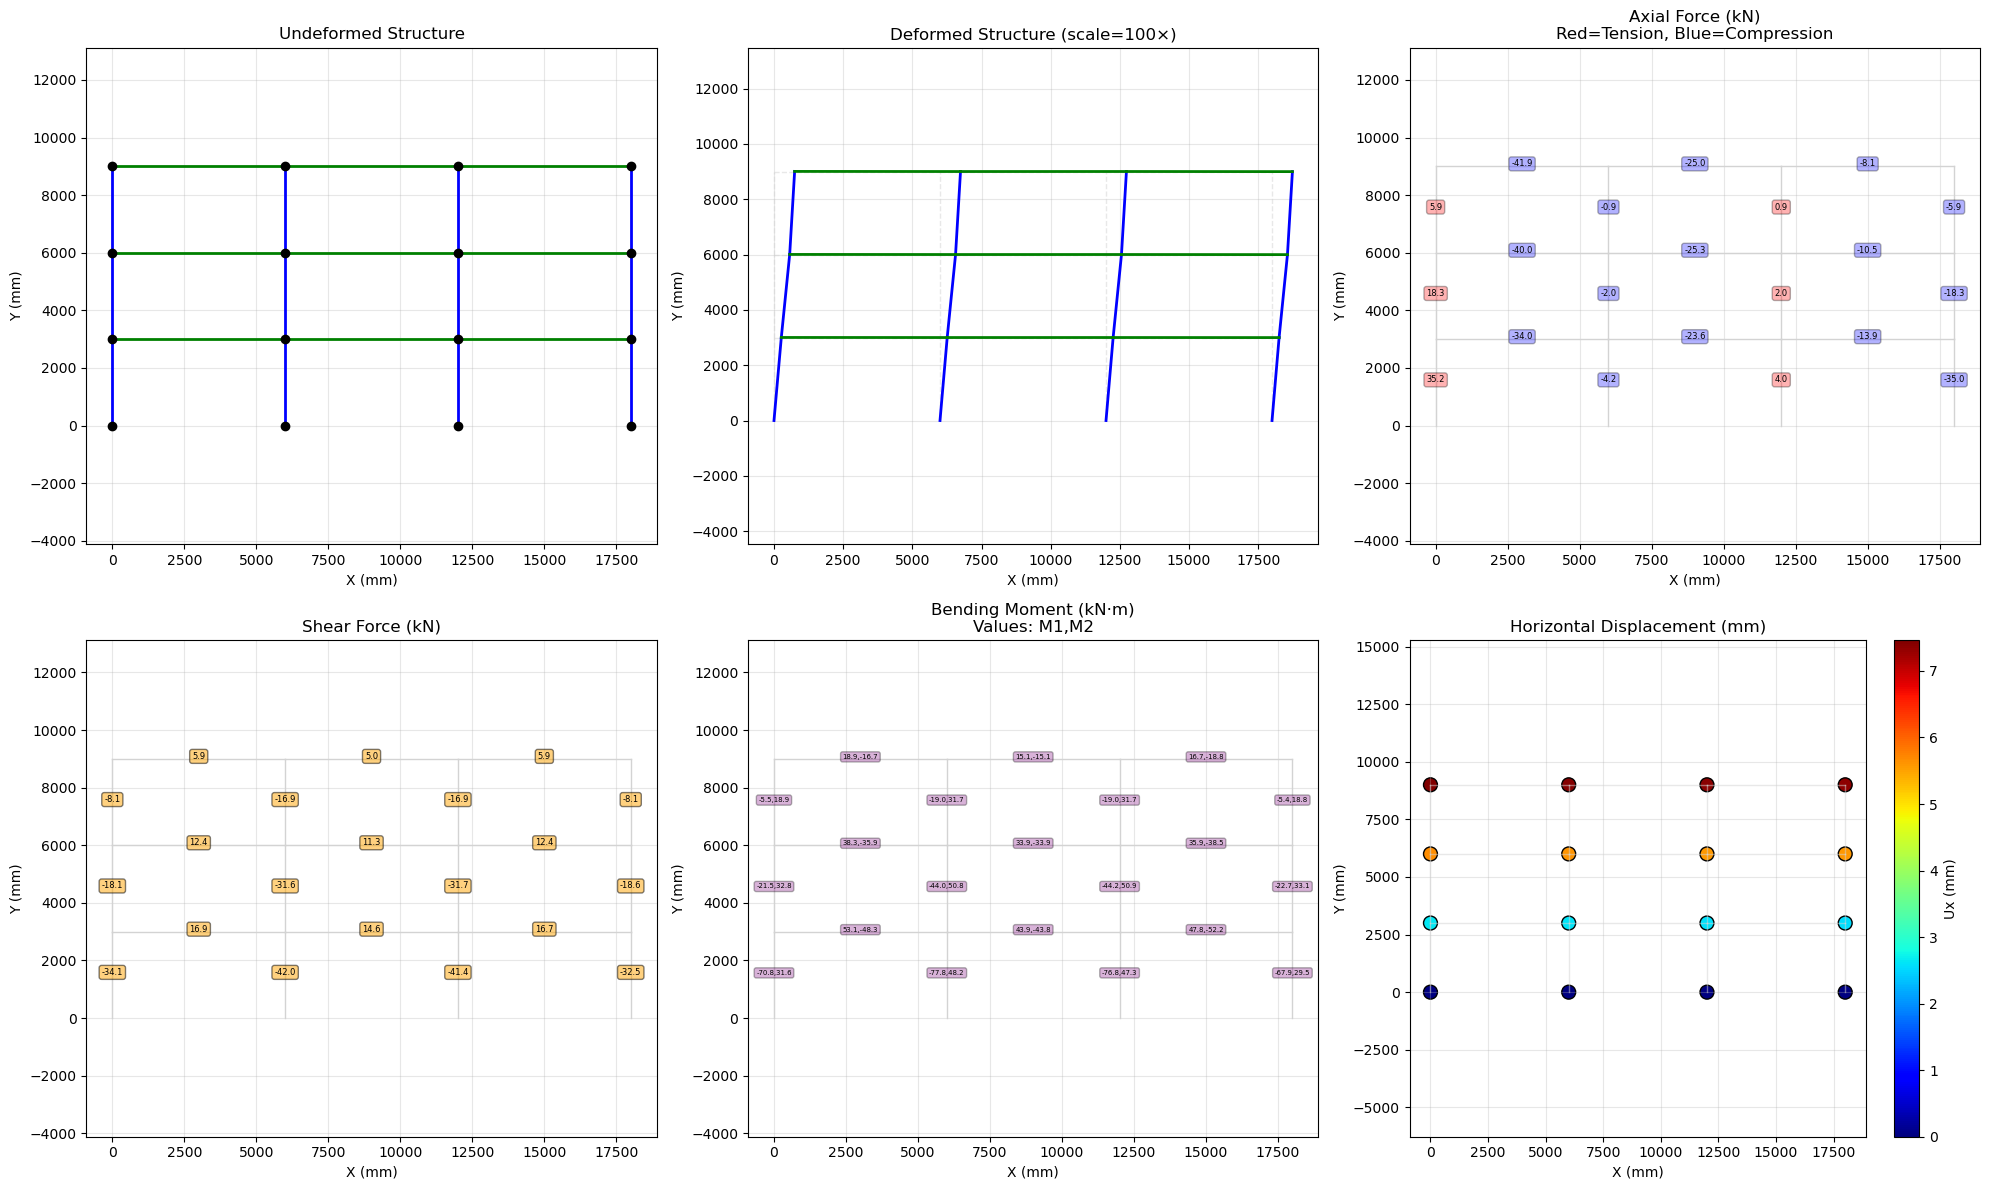


SUMMARY RESULTS

Maximum horizontal displacement: 7.4614 mm
Maximum vertical displacement: 0.0371 mm
Maximum rotation: 0.000919 rad

Maximum axial force: 41.87 kN
Maximum shear force: 42.01 kN
Maximum bending moment: 77.85 kN·m



In [5]:
# 首先在文件开头添加必要的导入
import csv
import pandas as pd

# Material and geometric properties
E = 3.0e4  # MPa
nu = 0.3
b = 400  # mm (out-of-plane width)
h = 400  # mm (in-plane height)
L_span = 6000  # mm
H_floor = 3000  # mm

# Section properties
A = b * h  # mm^2
I = b * h**3 / 12  # mm^4 (moment of inertia about z-axis)
G = E / (2 * (1 + nu))  # Shear modulus
A_s = 5/6 * A  # Effective shear area for rectangular section

# Generate nodal coordinates
nodes = {}
node_id = 0
for j in range(4):  # Y positions (floors)
    for i in range(4):  # X positions (bays)
        node_id += 1
        x = i * L_span
        y = j * H_floor
        nodes[node_id] = np.array([x, y])

print(f"Total nodes: {len(nodes)}")
print("Sample nodes:")
for nid in [1, 2, 5, 16]:
    print(f"  Node {nid}: {nodes[nid]}")

# Define elements (node1, node2)
elements = []

# Column elements (vertical)
for i in range(4):  # 4 X positions
    for j in range(3):  # 3 Y intervals
        node1 = j * 4 + i + 1
        node2 = (j + 1) * 4 + i + 1
        elements.append((node1, node2, 'column'))

# Beam elements (horizontal)
for j in range(1, 4):  # 3 floors (j=1,2,3 -> floor 2,3,4)
    for i in range(3):  # 3 X intervals
        node1 = j * 4 + i + 1
        node2 = j * 4 + i + 2
        elements.append((node1, node2, 'beam'))

print(f"\nTotal elements: {len(elements)}")
print(f"Columns: {sum(1 for e in elements if e[2] == 'column')}")
print(f"Beams: {sum(1 for e in elements if e[2] == 'beam')}")

# Element stiffness matrix in local coordinates (with shear deformation)
def local_stiffness_matrix(L, E, A, I, G, A_s):
    """
    2D Timoshenko beam element stiffness matrix (6x6)
    DOFs: [u1, v1, theta1, u2, v2, theta2]
    """
    phi = 12 * E * I / (G * A_s * L**2)  # Shear deformation parameter
    
    k = np.zeros((6, 6))
    
    # Axial terms
    k[0, 0] = E * A / L
    k[0, 3] = -E * A / L
    k[3, 0] = -E * A / L
    k[3, 3] = E * A / L
    
    # Bending terms with shear deformation
    k[1, 1] = 12 * E * I / (L**3 * (1 + phi))
    k[1, 2] = 6 * E * I / (L**2 * (1 + phi))
    k[1, 4] = -12 * E * I / (L**3 * (1 + phi))
    k[1, 5] = 6 * E * I / (L**2 * (1 + phi))
    
    k[2, 1] = 6 * E * I / (L**2 * (1 + phi))
    k[2, 2] = (4 + phi) * E * I / (L * (1 + phi))
    k[2, 4] = -6 * E * I / (L**2 * (1 + phi))
    k[2, 5] = (2 - phi) * E * I / (L * (1 + phi))
    
    k[4, 1] = -12 * E * I / (L**3 * (1 + phi))
    k[4, 2] = -6 * E * I / (L**2 * (1 + phi))
    k[4, 4] = 12 * E * I / (L**3 * (1 + phi))
    k[4, 5] = -6 * E * I / (L**2 * (1 + phi))
    
    k[5, 1] = 6 * E * I / (L**2 * (1 + phi))
    k[5, 2] = (2 - phi) * E * I / (L * (1 + phi))
    k[5, 4] = -6 * E * I / (L**2 * (1 + phi))
    k[5, 5] = (4 + phi) * E * I / (L * (1 + phi))
    
    return k

# Transformation matrix
def transformation_matrix(angle):
    """
    Transformation matrix from local to global coordinates
    """
    c = np.cos(angle)
    s = np.sin(angle)
    
    T = np.zeros((6, 6))
    T[0:2, 0:2] = [[c, s], [-s, c]]
    T[2, 2] = 1
    T[3:5, 3:5] = [[c, s], [-s, c]]
    T[5, 5] = 1
    
    return T

# Assemble global stiffness matrix
n_nodes = len(nodes)
n_dof = 3 * n_nodes  # 3 DOFs per node (ux, uy, theta_z)
K_global = np.zeros((n_dof, n_dof))

element_data = []

for elem_id, (n1, n2, elem_type) in enumerate(elements):
    coord1 = nodes[n1]
    coord2 = nodes[n2]
    
    dx = coord2[0] - coord1[0]
    dy = coord2[1] - coord1[1]
    L = np.sqrt(dx**2 + dy**2)
    angle = np.arctan2(dy, dx)
    
    # Local stiffness matrix
    k_local = local_stiffness_matrix(L, E, A, I, G, A_s)
    
    # Transformation matrix
    T = transformation_matrix(angle)
    
    # Global stiffness matrix for element
    k_global = T.T @ k_local @ T
    
    # Store element data
    element_data.append({
        'id': elem_id + 1,
        'nodes': (n1, n2),
        'length': L,
        'angle': angle,
        'angle_deg': np.degrees(angle),
        'type': elem_type,
        'T': T,
        'k_local': k_local,
        'k_global': k_global
    })
    
    # Assemble into global matrix
    dofs = [3*(n1-1), 3*(n1-1)+1, 3*(n1-1)+2, 3*(n2-1), 3*(n2-1)+1, 3*(n2-1)+2]
    
    for i in range(6):
        for j in range(6):
            K_global[dofs[i], dofs[j]] += k_global[i, j]

print(f"\nGlobal stiffness matrix size: {K_global.shape}")

# Apply boundary conditions
# Bottom nodes (j=0): nodes 1, 2, 3, 4 are fully fixed
fixed_dofs = []
for i in range(4):
    node = i + 1
    fixed_dofs.extend([3*(node-1), 3*(node-1)+1, 3*(node-1)+2])

# Apply loads
F_global = np.zeros(n_dof)

# Horizontal forces at node (1,2), (1,3), (1,4)
# Node (1,2) is node 5, (1,3) is node 9, (1,4) is node 13
load_nodes = [5, 9, 13]
F_magnitude = 50000  # N = 50 kN converted to N

for node in load_nodes:
    F_global[3*(node-1)] = F_magnitude  # Force in x-direction

# Partition system
free_dofs = [i for i in range(n_dof) if i not in fixed_dofs]

K_ff = K_global[np.ix_(free_dofs, free_dofs)]
F_f = F_global[free_dofs]

# Solve for displacements
U_f = solve(K_ff, F_f)

# Construct full displacement vector
U_global = np.zeros(n_dof)
U_global[free_dofs] = U_f

print("\nDisplacements at loaded nodes:")
for node in load_nodes:
    ux = U_global[3*(node-1)]
    uy = U_global[3*(node-1)+1]
    theta = U_global[3*(node-1)+2]
    print(f"  Node {node}: ux={ux:.4f} mm, uy={uy:.4f} mm, θz={theta:.6f} rad")

# ============================================
# 保存节点位移结果到CSV文件
# ============================================
print("\n" + "="*60)
print("SAVING NODE DISPLACEMENTS TO CSV")
print("="*60)

# 创建数据列表
node_data = []

for node_id in range(1, n_nodes + 1):
    # 获取节点坐标
    x = nodes[node_id][0]
    y = nodes[node_id][1]
    z = 0.0  # 2D结构，Z坐标为0
    
    # 获取节点坐标索引 (i, j) 从1开始计数
    # 计算行列索引 (1-based)
    # 节点编号公式: node_id = (j-1) * 4 + i
    j = (node_id - 1) // 4 + 1  # 行 (floor)
    i = (node_id - 1) % 4 + 1   # 列 (bay)
    node_coord = f"({i},{j})"
    
    # 获取位移和转角
    ux = U_global[3*(node_id-1)]     # U1 (mm) - 水平位移
    uy = U_global[3*(node_id-1)+1]   # U2 (mm) - 竖向位移
    uz = 0.0                         # U3 (mm) - 2D结构为0
    ur1 = 0.0                        # UR1 (rad) - 2D结构为0
    ur2 = 0.0                        # UR2 (rad) - 2D结构为0
    ur3 = U_global[3*(node_id-1)+2]  # UR3 (rad) - 转角
    
    # 计算总位移（2D平面）
    total_displacement = np.sqrt(ux**2 + uy**2)
    
    # 检查是否为固定节点（底部节点）
    is_fixed = 1 if node_id in [1, 2, 3, 4] else 0
    
    # 检查是否为加载节点
    is_loaded = 1 if node_id in load_nodes else 0
    
    # 添加到数据列表
    node_data.append({
        'Node': node_id,
        'Node_Coord': node_coord,
        'X': x,
        'Y': y,
        'Z': z,
        'Fixed': is_fixed,
        'Loaded': is_loaded,
        'U1': ux,
        'U2': uy,
        'U3': uz,
        'UR1': ur1,
        'UR2': ur2,
        'UR3': ur3,
        'Total_Displacement': total_displacement
    })

# 按节点编号排序（已经是从1到16的顺序）
node_data.sort(key=lambda x: x['Node'])

# 保存到CSV文件
csv_filename = "node_displacements_4_timoshenko.csv"
with open(csv_filename, 'w', newline='') as csvfile:
    fieldnames = ['Node', 'Node_Coord', 'X', 'Y', 'Z', 'Fixed', 'Loaded', 
                  'U1', 'U2', 'U3', 'UR1', 'UR2', 'UR3', 'Total_Displacement']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    writer.writeheader()
    for data in node_data:
        writer.writerow(data)

print(f"Node displacement data saved to '{csv_filename}'")

# 使用pandas读取并显示部分数据以供验证
df = pd.read_csv(csv_filename)
print(f"\nCSV文件包含 {len(df)} 个节点的数据")
print("\n前10个节点的数据:")
print(df.head(10).to_string(index=False))

# 显示统计信息
print("\n位移统计信息:")
print(f"最大水平位移 (U1): {df['U1'].abs().max():.6e} mm (节点 {df.loc[df['U1'].abs().idxmax(), 'Node']}, {df.loc[df['U1'].abs().idxmax(), 'Node_Coord']})")
print(f"最大竖向位移 (U2): {df['U2'].abs().max():.6e} mm (节点 {df.loc[df['U2'].abs().idxmax(), 'Node']}, {df.loc[df['U2'].abs().idxmax(), 'Node_Coord']})")
print(f"最大转角 (UR3): {df['UR3'].abs().max():.6e} rad (节点 {df.loc[df['UR3'].abs().idxmax(), 'Node']}, {df.loc[df['UR3'].abs().idxmax(), 'Node_Coord']})")
print(f"最大总位移: {df['Total_Displacement'].max():.6e} mm (节点 {df.loc[df['Total_Displacement'].idxmax(), 'Node']}, {df.loc[df['Total_Displacement'].idxmax(), 'Node_Coord']})")

# 显示固定节点的位移信息
fixed_data = df[df['Fixed'] == 1]
if len(fixed_data) > 0:
    print(f"\n固定节点编号: {fixed_data['Node'].tolist()}")
    print("固定节点的位移 (应为0或接近0):")
    print(fixed_data[['Node', 'Node_Coord', 'U1', 'U2', 'UR3', 'Total_Displacement']].to_string(index=False))

# 显示加载节点的位移信息
loaded_data = df[df['Loaded'] == 1]
if len(loaded_data) > 0:
    print(f"\n加载节点编号: {loaded_data['Node'].tolist()}")
    print("加载节点的位移:")
    print(loaded_data[['Node', 'Node_Coord', 'U1', 'U2', 'UR3', 'Total_Displacement']].to_string(index=False))

# 显示自由节点的最大位移
free_data = df[(df['Fixed'] == 0) & (df['Loaded'] == 0)]
if len(free_data) > 0:
    print(f"\n非加载自由节点中位移最大的5个节点:")
    top_5 = free_data.nlargest(5, 'Total_Displacement')[['Node', 'Node_Coord', 'Total_Displacement', 'U1', 'U2', 'UR3']]
    print(top_5.to_string(index=False))

# 可选：创建更详细的报告文件
report_filename = "displacement_report_4_timoshenko.txt"
with open(report_filename, 'w') as f:
    f.write("="*80 + "\n")
    f.write("NODE DISPLACEMENT ANALYSIS REPORT (Code 4 - Timoshenko)\n")
    f.write("="*80 + "\n\n")
    
    f.write(f"Analysis Parameters:\n")
    f.write(f"- Number of nodes: {n_nodes}\n")
    f.write(f"- Number of elements: {len(elements)}\n")
    f.write(f"- Applied load: 50 kN at nodes {load_nodes}\n")
    f.write(f"- Material: E = {E:.0f} MPa, ν = {nu}, G = {G:.2f} MPa\n")
    f.write(f"- Section: {b}x{h} mm, A = {A:.0f} mm², I = {I:.2e} mm⁴\n")
    f.write(f"- Shear effective area: A_s = {A_s:.0f} mm²\n\n")
    
    f.write("Displacement Summary:\n")
    f.write(f"- Maximum horizontal displacement: {df['U1'].abs().max():.6e} mm\n")
    f.write(f"- Maximum vertical displacement: {df['U2'].abs().max():.6e} mm\n")
    f.write(f"- Maximum rotation: {df['UR3'].abs().max():.6e} rad\n")
    f.write(f"- Maximum total displacement: {df['Total_Displacement'].max():.6e} mm\n\n")
    
    f.write("Top 10 nodes with largest total displacements:\n")
    top_10 = df.nlargest(10, 'Total_Displacement')[['Node', 'Node_Coord', 'Total_Displacement', 'U1', 'U2', 'UR3']]
    f.write(top_10.to_string(index=False) + "\n\n")
    
    f.write("Fixed nodes (bottom row):\n")
    f.write(fixed_data[['Node', 'Node_Coord']].to_string(index=False) + "\n\n")
    
    f.write("Loaded nodes (left side, upper floors):\n")
    f.write(loaded_data[['Node', 'Node_Coord']].to_string(index=False) + "\n\n")
    
    f.write("\n" + "="*80 + "\n")
    f.write("End of Report\n")
    f.write("="*80 + "\n")

print(f"\n详细报告已保存到 '{report_filename}'")

# ============================================
# 继续原有代码 - 计算单元内力
# ============================================

# Calculate element forces
element_forces = []

for elem_id, elem in enumerate(element_data):
    n1, n2 = elem['nodes']
    
    # Global DOFs
    dofs = [3*(n1-1), 3*(n1-1)+1, 3*(n1-1)+2, 3*(n2-1), 3*(n2-1)+1, 3*(n2-1)+2]
    u_global = U_global[dofs]
    
    # Transform to local coordinates
    u_local = elem['T'] @ u_global
    
    # Calculate local forces
    f_local = elem['k_local'] @ u_local
    
    # Extract internal forces
    N1 = -f_local[0]  # Axial force at node 1
    V1 = -f_local[1]  # Shear force at node 1
    M1 = -f_local[2]  # Moment at node 1
    N2 = f_local[3]   # Axial force at node 2
    V2 = f_local[4]   # Shear force at node 2
    M2 = f_local[5]   # Moment at node 2
    
    element_forces.append({
        'N1': N1, 'V1': V1, 'M1': M1,
        'N2': N2, 'V2': V2, 'M2': M2
    })

# 保存单元内力到CSV文件
element_force_data = []

for elem_id, elem in enumerate(element_data):
    ef = element_forces[elem_id]
    n1, n2 = elem['nodes']
    
    # 计算节点坐标索引
    j1 = (n1 - 1) // 4 + 1
    i1 = (n1 - 1) % 4 + 1
    j2 = (n2 - 1) // 4 + 1
    i2 = (n2 - 1) % 4 + 1
    
    # 确定单元类型和位置
    if elem['type'] == 'column':
        elem_location = f"Column at X{i1}, Floors {j1}-{j2}"
    else:  # beam
        elem_location = f"Beam at Floor {j1}, Bays {i1}-{i2}"
    
    element_force_data.append({
        'Element': elem_id + 1,
        'Type': elem['type'],
        'Node1': n1,
        'Node2': n2,
        'Node1_Coord': f"({i1},{j1})",
        'Node2_Coord': f"({i2},{j2})",
        'Length': elem['length'],
        'Angle_deg': elem['angle_deg'],
        'Location': elem_location,
        'N1_kN': ef['N1'] / 1000,
        'V1_kN': ef['V1'] / 1000,
        'M1_kNm': ef['M1'] / 1e6,
        'N2_kN': ef['N2'] / 1000,
        'V2_kN': ef['V2'] / 1000,
        'M2_kNm': ef['M2'] / 1e6,
        'N_avg_kN': (ef['N1'] + ef['N2']) / (2 * 1000),
        'V_avg_kN': (ef['V1'] + ef['V2']) / (2 * 1000),
        'M_max_kNm': max(abs(ef['M1']), abs(ef['M2'])) / 1e6
    })

# 保存单元内力到CSV
elem_csv_filename = "element_forces_4_timoshenko.csv"
with open(elem_csv_filename, 'w', newline='') as csvfile:
    fieldnames = ['Element', 'Type', 'Node1', 'Node2', 'Node1_Coord', 'Node2_Coord', 
                  'Length', 'Angle_deg', 'Location',
                  'N1_kN', 'V1_kN', 'M1_kNm', 'N2_kN', 'V2_kN', 'M2_kNm',
                  'N_avg_kN', 'V_avg_kN', 'M_max_kNm']
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    
    writer.writeheader()
    for data in element_force_data:
        writer.writerow(data)

print(f"Element forces data saved to '{elem_csv_filename}'")

# 显示单元内力统计信息
print("\n单元内力统计信息:")
max_N = max([abs(ef['N1']) for ef in element_forces])
max_V = max([abs(ef['V1']) for ef in element_forces])
max_M = max([abs(ef['M1']) for ef in element_forces])
print(f"最大轴力: {max_N/1000:.2f} kN")
print(f"最大剪力: {max_V/1000:.2f} kN")
print(f"最大弯矩: {max_M/1e6:.2f} kN·m")

# Convert to kN and kN·m for display
print("\nElement Forces (first 5 elements):")
for i in range(min(5, len(elements))):
    ef = element_forces[i]
    print(f"  Element {i+1} ({elements[i][2]}): N1={ef['N1']/1000:.2f} kN, "
          f"V1={ef['V1']/1000:.2f} kN, M1={ef['M1']/1e6:.2f} kN·m")

# Visualization
fig = plt.figure(figsize=(20, 12))

# 1. Undeformed structure
ax1 = plt.subplot(2, 3, 1)
for elem_id, (n1, n2, elem_type) in enumerate(elements):
    x = [nodes[n1][0], nodes[n2][0]]
    y = [nodes[n1][1], nodes[n2][1]]
    color = 'blue' if elem_type == 'column' else 'green'
    ax1.plot(x, y, color=color, linewidth=2)

for node_id, coord in nodes.items():
    ax1.plot(coord[0], coord[1], 'ko', markersize=6)
    
ax1.set_xlabel('X (mm)')
ax1.set_ylabel('Y (mm)')
ax1.set_title('Undeformed Structure')
ax1.grid(True, alpha=0.3)
ax1.axis('equal')

# 2. Deformed structure
ax2 = plt.subplot(2, 3, 2)
scale = 100  # Amplification factor for visibility

for elem_id, (n1, n2, elem_type) in enumerate(elements):
    x = [nodes[n1][0], nodes[n2][0]]
    y = [nodes[n1][1], nodes[n2][1]]
    color = 'lightgray'
    ax2.plot(x, y, color=color, linewidth=1, linestyle='--', alpha=0.5)

for elem_id, (n1, n2, elem_type) in enumerate(elements):
    x1_def = nodes[n1][0] + scale * U_global[3*(n1-1)]
    y1_def = nodes[n1][1] + scale * U_global[3*(n1-1)+1]
    x2_def = nodes[n2][0] + scale * U_global[3*(n2-1)]
    y2_def = nodes[n2][1] + scale * U_global[3*(n2-1)+1]
    
    color = 'blue' if elem_type == 'column' else 'green'
    ax2.plot([x1_def, x2_def], [y1_def, y2_def], color=color, linewidth=2)

ax2.set_xlabel('X (mm)')
ax2.set_ylabel('Y (mm)')
ax2.set_title(f'Deformed Structure (scale={scale}×)')
ax2.grid(True, alpha=0.3)
ax2.axis('equal')

# 3. Axial force diagram
ax3 = plt.subplot(2, 3, 3)
for elem_id, (n1, n2, elem_type) in enumerate(elements):
    x = [nodes[n1][0], nodes[n2][0]]
    y = [nodes[n1][1], nodes[n2][1]]
    ax3.plot(x, y, color='lightgray', linewidth=1)
    
    N_avg = (element_forces[elem_id]['N1'] + element_forces[elem_id]['N2']) / 2 / 1000
    xm = (nodes[n1][0] + nodes[n2][0]) / 2
    ym = (nodes[n1][1] + nodes[n2][1]) / 2
    
    color = 'red' if N_avg > 0 else 'blue'
    ax3.text(xm, ym, f'{N_avg:.1f}', fontsize=6, ha='center', 
             bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3))

ax3.set_xlabel('X (mm)')
ax3.set_ylabel('Y (mm)')
ax3.set_title('Axial Force (kN)\nRed=Tension, Blue=Compression')
ax3.grid(True, alpha=0.3)
ax3.axis('equal')

# 4. Shear force diagram
ax4 = plt.subplot(2, 3, 4)
for elem_id, (n1, n2, elem_type) in enumerate(elements):
    x = [nodes[n1][0], nodes[n2][0]]
    y = [nodes[n1][1], nodes[n2][1]]
    ax4.plot(x, y, color='lightgray', linewidth=1)
    
    V_avg = (element_forces[elem_id]['V1'] + element_forces[elem_id]['V2']) / 2 / 1000
    xm = (nodes[n1][0] + nodes[n2][0]) / 2
    ym = (nodes[n1][1] + nodes[n2][1]) / 2
    
    if abs(V_avg) > 0.1:
        ax4.text(xm, ym, f'{V_avg:.1f}', fontsize=6, ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='orange', alpha=0.5))

ax4.set_xlabel('X (mm)')
ax4.set_ylabel('Y (mm)')
ax4.set_title('Shear Force (kN)')
ax4.grid(True, alpha=0.3)
ax4.axis('equal')

# 5. Bending moment diagram
ax5 = plt.subplot(2, 3, 5)
for elem_id, (n1, n2, elem_type) in enumerate(elements):
    x = [nodes[n1][0], nodes[n2][0]]
    y = [nodes[n1][1], nodes[n2][1]]
    ax5.plot(x, y, color='lightgray', linewidth=1)
    
    M1 = element_forces[elem_id]['M1'] / 1e6  # Convert to kN·m
    M2 = element_forces[elem_id]['M2'] / 1e6
    
    xm = (nodes[n1][0] + nodes[n2][0]) / 2
    ym = (nodes[n1][1] + nodes[n2][1]) / 2
    
    if abs(M1) > 0.1 or abs(M2) > 0.1:
        ax5.text(xm, ym, f'{M1:.1f},{M2:.1f}', fontsize=5, ha='center',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='purple', alpha=0.3))

ax5.set_xlabel('X (mm)')
ax5.set_ylabel('Y (mm)')
ax5.set_title('Bending Moment (kN·m)\nValues: M1,M2')
ax5.grid(True, alpha=0.3)
ax5.axis('equal')

# 6. Horizontal displacement contour
ax6 = plt.subplot(2, 3, 6)
x_coords = [nodes[i][0] for i in range(1, n_nodes+1)]
y_coords = [nodes[i][1] for i in range(1, n_nodes+1)]
u_x = [U_global[3*(i-1)] for i in range(1, n_nodes+1)]

scatter = ax6.scatter(x_coords, y_coords, c=u_x, s=100, cmap='jet', edgecolors='black')
plt.colorbar(scatter, ax=ax6, label='Ux (mm)')

for elem_id, (n1, n2, elem_type) in enumerate(elements):
    x = [nodes[n1][0], nodes[n2][0]]
    y = [nodes[n1][1], nodes[n2][1]]
    ax6.plot(x, y, color='lightgray', linewidth=1, alpha=0.5)

ax6.set_xlabel('X (mm)')
ax6.set_ylabel('Y (mm)')
ax6.set_title('Horizontal Displacement (mm)')
ax6.grid(True, alpha=0.3)
ax6.axis('equal')

plt.tight_layout()
plt.savefig('frame_analysis_4_timoshenko.png', dpi=150, bbox_inches='tight')
plt.show()

# Print summary results
print("\n" + "="*60)
print("SUMMARY RESULTS")
print("="*60)
print(f"\nMaximum horizontal displacement: {max(u_x):.4f} mm")
print(f"Maximum vertical displacement: {max([U_global[3*i+1] for i in range(n_nodes)]):.4f} mm")
print(f"Maximum rotation: {max([abs(U_global[3*i+2]) for i in range(n_nodes)]):.6f} rad")

print(f"\nMaximum axial force: {max_N/1000:.2f} kN")
print(f"Maximum shear force: {max_V/1000:.2f} kN")
print(f"Maximum bending moment: {max_M/1e6:.2f} kN·m")

print("\n" + "="*60)